In [1]:
# Cell 1 — imports
from lifelines import KaplanMeierFitter
import pandas as pd
import matplotlib.pyplot as plt

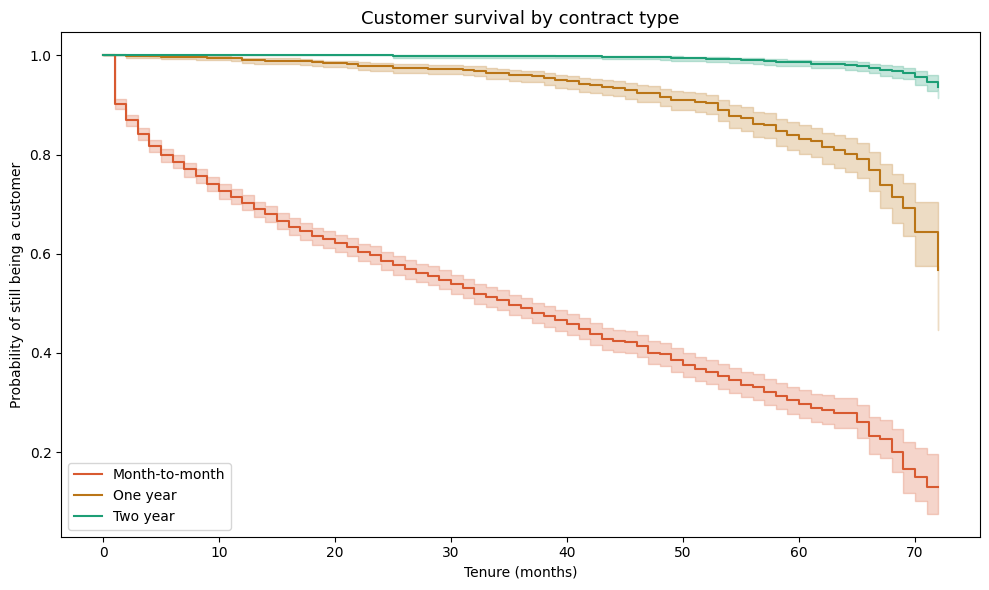

In [2]:
# Cell 2 — customer survival by contract type
df_c = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_c['churned'] = (df_c['Churn'] == 'Yes').astype(int)

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

colors = {'Month-to-month': '#D85A30',
          'One year': '#BA7517',
          'Two year': '#1D9E75'}

for contract, color in colors.items():
    mask = df_c['Contract'] == contract
    kmf.fit(df_c[mask]['tenure'],
            event_observed=df_c[mask]['churned'],
            label=contract)
    kmf.plot_survival_function(ax=ax, color=color, ci_show=True)

ax.set_title('Customer survival by contract type', fontsize=13)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Probability of still being a customer')
plt.tight_layout()
plt.savefig('../outputs/survival_customer.png', dpi=150, bbox_inches='tight')
plt.show()

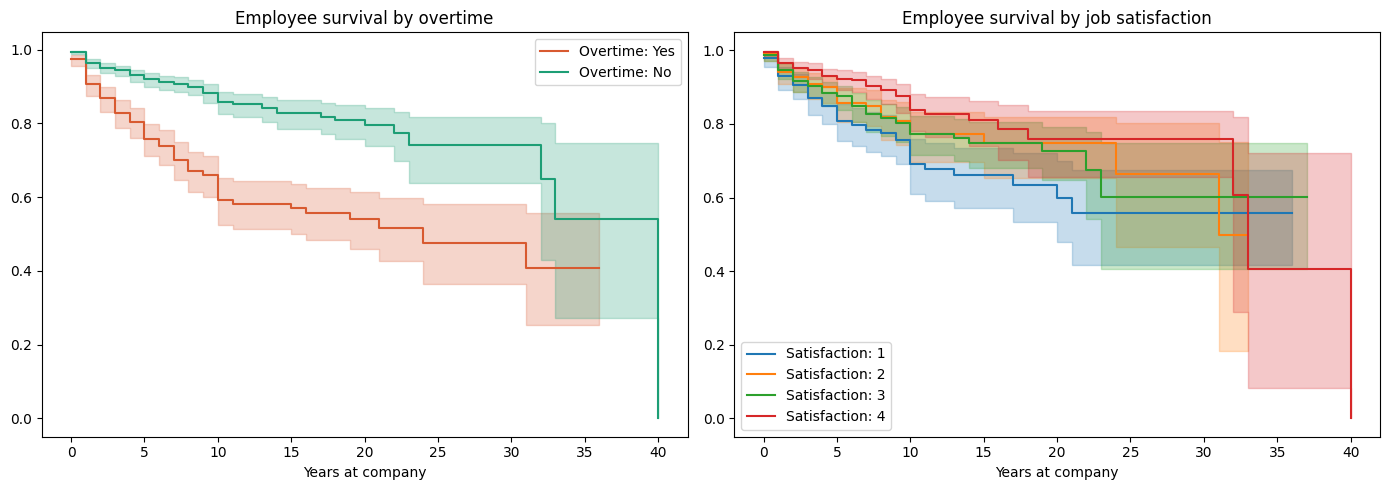

In [4]:
# Cell 3 — employee survival by overtime status
df_e = pd.read_csv('../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_e['left'] = (df_e['Attrition'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival by OverTime
for ot, color in [('Yes','#D85A30'),('No','#1D9E75')]:
    mask = df_e['OverTime'] == ot
    kmf.fit(df_e[mask]['YearsAtCompany'],
            event_observed=df_e[mask]['left'],
            label=f'Overtime: {ot}')
    kmf.plot_survival_function(ax=axes[0], color=color)
axes[0].set_title('Employee survival by overtime')
axes[0].set_xlabel('Years at company')

# Survival by JobSatisfaction level
for level in [1, 2, 3, 4]:
    mask = df_e['JobSatisfaction'] == level
    kmf.fit(df_e[mask]['YearsAtCompany'],
            event_observed=df_e[mask]['left'],
            label=f'Satisfaction: {level}')
    kmf.plot_survival_function(ax=axes[1])
axes[1].set_title('Employee survival by job satisfaction')
axes[1].set_xlabel('Years at company')

plt.tight_layout()
plt.savefig('../outputs/survival_employee.png', dpi=150, bbox_inches='tight')
plt.show()